# Load and Explore Pulse Analysis Results
This notebook will help you load previously saved pulse analysis results, select clusters based on thresholds, and visualize changes within and across sessions.

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Utility function to load a results pickle
def load_analysis_results(session_id, results_dir='pkls'):
    pkl_path = os.path.join(results_dir, f'fast_slow_results_{session_id}.pkl')
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
    print(f"Loaded results from {pkl_path}")
    return results

## Specify Session and Load Data
Enter the session ID for the data you want to explore. The results will be loaded from the corresponding pickle file.

In [2]:
os.getcwd()

'e:\\python_analysis\\git_repos\\vis_detect_analysis_Apr2023\\scripts'

In [20]:
# Example: session_id = 'BG_031_08052025'
session_id = 'BG_031_08052025'  # Change as needed
results = load_analysis_results(session_id)

# Unpack variables for convenience
z_fast = results['z_fast']
z_slow = results['z_slow']
z_sem_fast = results['z_sem_fast']
z_sem_slow = results['z_sem_slow']
t_vec = results['t_vec']
mean_fast = results['mean_fast']
mean_slow = results['mean_slow']
sem_fast = results['sem_fast']
sem_slow = results['sem_slow']
pre_window = results['pre_window']
post_window = results['post_window']

Loaded results from pkls\fast_slow_results_BG_031_08052025.pkl


## Cluster Selection by Threshold
Select clusters based on a threshold of response (e.g., max z-score in a window after the pulse). Adjust the threshold as needed.

In [21]:
# Parameters for selection
threshold = 4.0  # Example: select clusters with max z-score > 2 after pulse
window = [0, 0.5]  # Time window after pulse (in seconds)

# Find indices for the window
window_mask = (t_vec >= window[0]) & (t_vec < window[1])

# Select clusters
selected_clusters = [clu for clu, z in z_fast.items() if np.max(z[window_mask]) > threshold]
print(f"Selected {len(selected_clusters)} clusters with max z > {threshold} in {window} s after pulse.")

Selected 16 clusters with max z > 4.0 in [0, 0.5] s after pulse.


In [22]:
# Additional filter: Exclude clusters with significant pre-pulse activity
pre_window = [-0.05, 0]  # Adjust as needed
pre_mask = (t_vec >= pre_window[0]) & (t_vec < pre_window[1])
pre_activity_threshold = 2.0  # Example threshold for significant pre-pulse activity

filtered_clusters = []
for clu in selected_clusters:
    pre_max = np.max(np.abs(z_fast[clu][pre_mask]))
    if pre_max < pre_activity_threshold:
        filtered_clusters.append(clu)
    else:
        print(f"Excluding cluster {clu} due to high pre-pulse activity (max abs z = {pre_max:.2f})")

print(f"Filtered to {len(filtered_clusters)} clusters after removing those with significant pre-pulse activity.")
selected_clusters = filtered_clusters

Excluding cluster 81 due to high pre-pulse activity (max abs z = 2.14)
Excluding cluster 355 due to high pre-pulse activity (max abs z = 2.16)
Filtered to 14 clusters after removing those with significant pre-pulse activity.


## Visualize Selected Clusters
Plot the PSTH for the selected clusters (fast and slow pulses, with SEM shading).

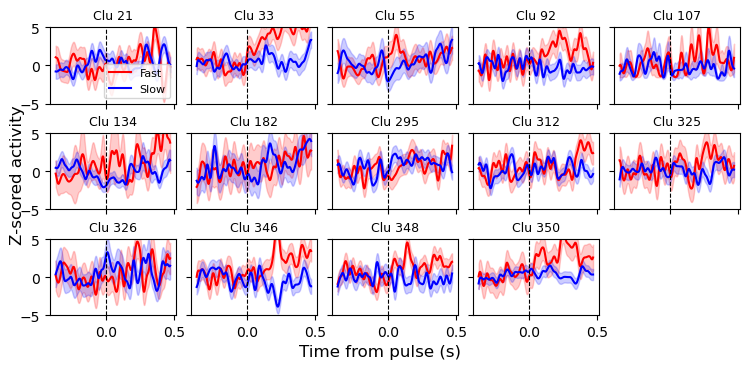

In [7]:
def plot_selected_clusters(z_fast, z_slow, t_vec, sem_fast, sem_slow, clusters, n_cols=5, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    n_plot = len(clusters)
    n_rows = int(np.ceil(n_plot / n_cols))
    sigma = sigma_ms / 1000 / dt
    trim = int(np.ceil(trim_sigma * sigma))
    t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for idx, clu in enumerate(clusters):
        ax = axes[idx]
        zf = z_fast[clu][trim:-trim] if trim > 0 else z_fast[clu]
        zs = z_slow[clu][trim:-trim] if trim > 0 else z_slow[clu]
        sf = sem_fast[clu][trim:-trim] if trim > 0 else sem_fast[clu]
        ss = sem_slow[clu][trim:-trim] if trim > 0 else sem_slow[clu]
        ax.plot(t_vec_trim, zf, color='r', label='Fast')
        ax.plot(t_vec_trim, zs, color='b', label='Slow')
        ax.fill_between(t_vec_trim, zf - sf, zf + sf, color='r', alpha=0.2)
        ax.fill_between(t_vec_trim, zs - ss, zs + ss, color='b', alpha=0.2)
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_ylim(-5, 5)
        ax.set_title(f'Clu {clu}', fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_plot:]:
        ax.axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    fig.text(0.007, 0.5, 'Z-scored activity', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.007, 'Time from pulse (s)', ha='center', va='center', fontsize=12)
    plt.show()

# Plot selected clusters
plot_selected_clusters(z_fast, z_slow, t_vec, z_sem_fast, z_sem_slow, selected_clusters)

In [19]:
# calcuate a subtraction of the fast and slow z-scores for the clurters that were selected
def calculate_z_difference(z_fast, z_slow):
    z_diff = {}
    for clu in z_fast.keys():
        z_diff[clu] = np.abs(z_fast[clu] - z_slow[clu])
    return z_diff

# Calculate the difference between fast and slow z-scores
z_diff = calculate_z_difference(z_fast, z_slow)

# function to plot withhot sem: 
def plot_z_difference(z_diff, t_vec, clusters, n_cols=5, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    n_plot = len(clusters)
    n_rows = int(np.ceil(n_plot / n_cols))
    sigma = sigma_ms / 1000 / dt
    trim = int(np.ceil(trim_sigma * sigma))
    t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for idx, clu in enumerate(clusters):
        ax = axes[idx]
        zd = z_diff[clu][trim:-trim] if trim > 0 else z_diff[clu]
        ax.plot(t_vec_trim, zd, color='k', label='Z Difference')
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_ylim(0, np.max(zd) + 1)
        ax.set_title(f'Clu {clu}', fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_plot:]:
        ax.axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    fig.text(0.007, 0.5, 'Z Difference (Fast - Slow)', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.007, 'Time from pulse (s)', ha='center', va='center', fontsize=12)
    plt.show()


In [23]:
post_window = [0, 0.5]
post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])
responsivity_threshold = 5.0  # or another value based on your data

final_clusters = []
for clu in selected_clusters:
    max_resp = np.max(z_diff[clu][post_mask])
    if max_resp > responsivity_threshold:
        final_clusters.append(clu)
    else:
        print(f"Excluding cluster {clu} due to low post-pulse responsivity (max diff = {max_resp:.2f})")
print(f"Final selection: {len(final_clusters)} clusters with real responsivity.")
selected_clusters = final_clusters

Excluding cluster 55 due to low post-pulse responsivity (max diff = 4.38)
Excluding cluster 107 due to low post-pulse responsivity (max diff = 4.61)
Excluding cluster 182 due to low post-pulse responsivity (max diff = 4.82)
Excluding cluster 312 due to low post-pulse responsivity (max diff = 4.21)
Excluding cluster 325 due to low post-pulse responsivity (max diff = 4.62)
Final selection: 9 clusters with real responsivity.


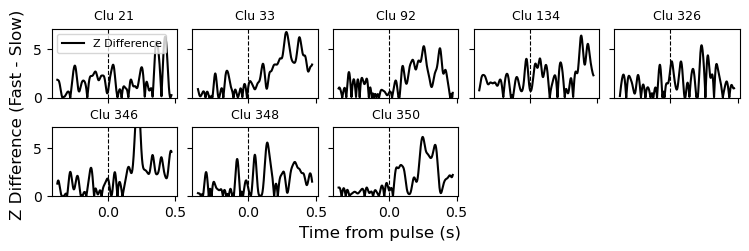

In [ ]:
# if 295 in selected_clusters:
#     selected_clusters.remove(295)
# Plot the z-score differences
plot_z_difference(z_diff, t_vec, selected_clusters)


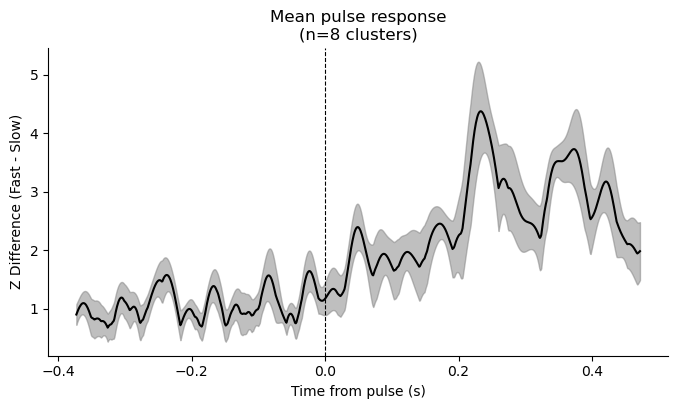

Number of clusters plotted: 8


In [31]:
# Calculate the mean and SEM of the z-score differences for the selected clusters
def calculate_mean_sem(z_diff, clusters):
    mean_diff = np.zeros_like(next(iter(z_diff.values())))
    sem_diff = np.zeros_like(mean_diff)
    for clu in clusters:
        mean_diff += z_diff[clu]
        sem_diff += z_diff[clu] ** 2  # Variance for SEM
    n_clusters = len(clusters)
    mean_diff /= n_clusters
    sem_diff = np.sqrt(sem_diff / n_clusters - mean_diff ** 2) / np.sqrt(n_clusters)  # SEM calculation
    return mean_diff, sem_diff

mean_diff, sem_diff = calculate_mean_sem(z_diff, selected_clusters)
# Plot the mean and SEM of the z-score differences
def plot_mean_sem_diff(mean_diff, sem_diff, t_vec, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    sigma = sigma_ms / 1000 / dt
    trim = int(np.ceil(trim_sigma * sigma))
    t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
    mean_diff_trim = mean_diff[trim:-trim] if trim > 0 else mean_diff
    sem_diff_trim = sem_diff[trim:-trim] if trim > 0 else sem_diff

    plt.figure(figsize=(8, 4))
    plt.plot(t_vec_trim, mean_diff_trim, color='k', label='Mean Z Difference')
    plt.fill_between(t_vec_trim, mean_diff_trim - sem_diff_trim, mean_diff_trim + sem_diff_trim,
                     color='gray', alpha=0.5, label='SEM')
    plt.axvline(0, color='k', linestyle='--', lw=0.8)
    plt.xlabel('Time from pulse (s)')
    plt.ylabel('Z Difference (Fast - Slow)')
    n_clusters = len(selected_clusters)
    plt.title(f'Mean pulse response\n(n={n_clusters} clusters)')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()
    print(f'Number of clusters plotted: {n_clusters}')
plot_mean_sem_diff(mean_diff, sem_diff, t_vec)

## Next Steps
- Adjust the threshold or window to refine cluster selection.
- Compare selected clusters across sessions by loading other session pickles.
- Add further analyses or visualizations as needed.